In [ ]:
#Final Project Draft: [Student Dropout Prediction]
Kennedy Madison
Due: 4/5/26

In [ ]:
## 1. Problem Statement & Dataset
[How can we predict whether a student will drop out of school and can we prevent it? The data set provides different demographics and categories that can help us identfy possible patterns of a student drop out incident]

In [31]:
## Data Loading & Exploration
import pandas as pd

df = pd.read_csv("student_dropout_dataset_v3.csv")  # make sure name matches exactly

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [33]:
df.isnull().sum()


Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [35]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


C:\Users\kgmad\AppData\Local\Temp\ipykernel_164\4216477938.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [36]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [37]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [43]:
## 3. Feature Engineering
df['low_income'] = (df['Family_Income'] < df['Family_Income'].median()).astype(int)

In [42]:
df['high_stress'] = (df['Stress_Index'] >= 7).astype(int)

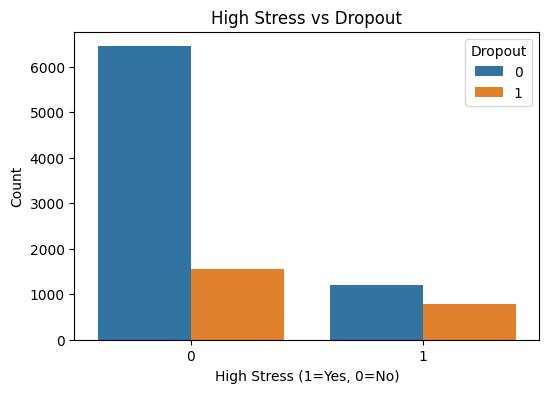

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='high_stress', hue='Dropout', data=df)
plt.title('High Stress vs Dropout')
plt.xlabel('High Stress (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

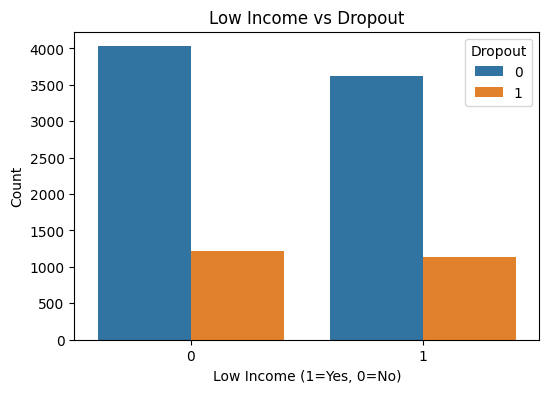

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='low_income', hue='Dropout', data=df)
plt.title('Low Income vs Dropout')
plt.xlabel('Low Income (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

In [52]:
## 4. Data Preprocessing
from sklearn.model_selection import train_test_split
X = df[['Stress_Index', 'Family_Income', 'high_stress', 'low_income']]
y = df['Dropout']  # or 'target' if your dataset renamed it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())

X_train shape: (8000, 4)
X_test shape: (2000, 4)
y_train distribution:
 Dropout
0    6117
1    1883
Name: count, dtype: int64
y_test distribution:
 Dropout
0    1529
1     471
Name: count, dtype: int64


In [53]:
scaler = StandardScaler()

# Numeric features to scale
numeric_features = ['Stress_Index', 'Family_Income']

# Fit on train, transform both train and test
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Quick check
X_train.head()

,Stress_Index,Family_Income,high_stress,low_income
4565,2.415356,-0.387662,1,0
3663,1.895382,1.667159,1,0
8964,-0.473385,0.785896,0,0
5778,0.624336,-0.315545,0,0
9938,0.451012,-0.640744,0,1


In [74]:
## 5. Model 1: [Random Forest]
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier( n_estimators=100,max_depth=None,min_samples_split=10,min_samples_leaf=2,max_features='sqrt',class_weight='balanced' ,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)






Accuracy: 0.669
              precision    recall  f1-score   support

           0       0.81      0.74      0.77      1529
           1       0.34      0.45      0.39       471

    accuracy                           0.67      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.70      0.67      0.68      2000



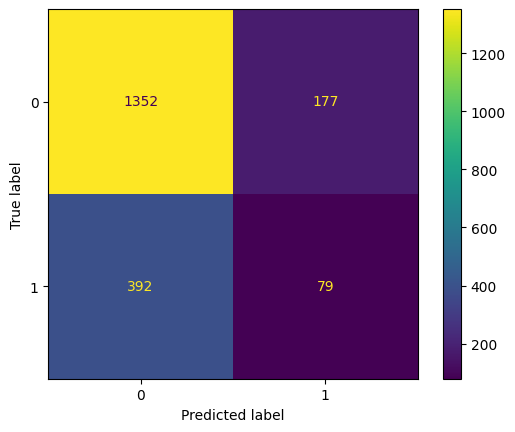

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

In [ ]:
## 6. Model 2: [log reg]
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print( accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.7655
              precision    recall  f1-score   support

           0       0.77      0.99      0.87      1529
           1       0.53      0.04      0.07       471

    accuracy                           0.77      2000
   macro avg       0.65      0.51      0.47      2000
weighted avg       0.71      0.77      0.68      2000



In [77]:
## 7. Model Comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.6690
1,Logistic Regression,0.7655


In [8]:
## 8. Next Steps & Reflection
